In [3]:
!wget -O sign_mnist_train.csv https://raw.githubusercontent.com/Elsaraf1/sign-language/master/sign_mnist_train.csv
!wget -O sign_mnist_test.csv  https://raw.githubusercontent.com/Elsaraf1/sign-language/master/sign_mnist_test.csv


--2025-11-23 17:20:25--  https://raw.githubusercontent.com/Elsaraf1/sign-language/master/sign_mnist_train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 83253609 (79M) [text/plain]
Saving to: ‘sign_mnist_train.csv’

sign_mnist_train.cs 100%[===================>]  79.40M   178MB/s    in 0.4s    

2025-11-23 17:20:28 (178 MB/s) - ‘sign_mnist_train.csv’ saved [83253609/83253609]

--2025-11-23 17:20:28--  https://raw.githubusercontent.com/Elsaraf1/sign-language/master/sign_mnist_test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Le

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [5]:
# Load the CSV files
train_df = pd.read_csv("sign_mnist_train.csv")
test_df  = pd.read_csv("sign_mnist_test.csv")

print(train_df.shape, test_df.shape)
train_df.head()


(27455, 785) (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [6]:
# Labels (classes you're trying to predict)
y_train = train_df['label'].values
y_test  = test_df['label'].values

# Pixel values (features)
X_train = train_df.drop('label', axis=1).values
X_test  = test_df.drop('label', axis=1).values

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(27455, 784) (27455,)
(7172, 784) (7172,)


In [7]:
# Scale pixels from [0, 255] to [0, 1]
X_train = X_train / 255.0
X_test  = X_test / 255.0

# Reshape to image format: (n_samples, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape, X_test.shape)


(27455, 28, 28, 1) (7172, 28, 28, 1)


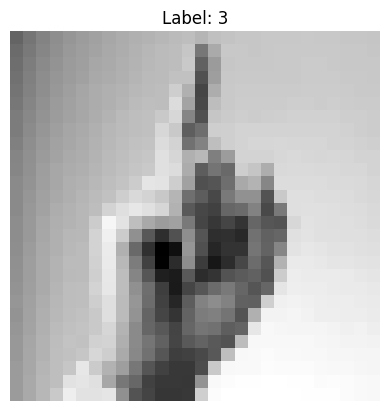

In [8]:
# Show the first training image
index = 0  # you can change this number to see other images

image = X_train[index].reshape(28, 28)
label = y_train[index]

plt.imshow(image, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()


In [9]:
# Use max label + 1 so labels 0..max are all valid
num_classes = int(y_train.max()) + 1
print("Number of classes (using max+1):", num_classes)

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),   # input layer

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPool2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # final layer uses num_classes (should be 25)
    layers.Dense(num_classes, activation='softmax')
])

model.summary()


Number of classes (using max+1): 25


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,969 (886.60 KB)

 Trainable params: 226,969 (886.60 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [11]:
history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - accuracy: 0.2879 - loss: 2.5003 - val_accuracy: 0.7720 - val_loss: 0.7002
Epoch 2/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.8413 - loss: 0.5296 - val_accuracy: 0.9228 - val_loss: 0.2408
Epoch 3/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - accuracy: 0.9489 - loss: 0.1866 - val_accuracy: 0.9909 - val_loss: 0.0719
Epoch 4/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - accuracy: 0.9946 - loss: 0.0510 - val_accuracy: 0.9993 - val_loss: 0.0246
Epoch 5/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - accuracy: 0.9994 - loss: 0.0190 - val_accuracy: 1.0000 - val_loss: 0.0123
Epoch 6/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 22s 97ms/step - accuracy: 0.9998 - loss: 0.0105 - val_accuracy: 1.0000 - val_loss: 0.0068
Epoch 7/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - accuracy: 0.9997 - loss: 0.0062 - val_accuracy: 1.0000 - val_loss: 0.0064
Epoch 8/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - accuracy: 1.0000 - loss: 0.0038 -

In [13]:
print("Min label:", y_train.min())
print("Max label:", y_train.max())
print("Number of unique labels:", len(np.unique(y_train)))


Min label: 0
Max label: 24
Number of unique labels: 24


In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)


Test Accuracy: 0.9149470329284668
Test Loss: 0.35277214646339417


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


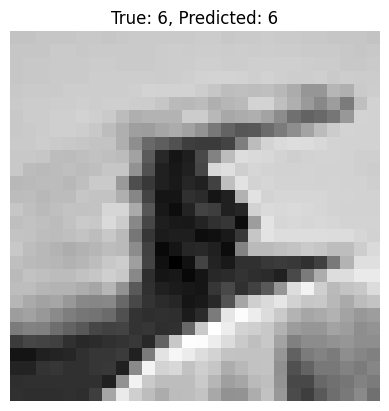

Prediction vector: [[1.12728776e-23 2.81675682e-15 4.00669933e-06 1.94493488e-08
  2.41051732e-12 5.29054546e-07 9.99976039e-01 4.00359923e-09
  1.62544037e-13 5.37294228e-24 4.90348701e-13 8.59613465e-06
  2.12428144e-12 1.91025581e-14 1.03851062e-05 9.48855924e-11
  7.21969984e-11 1.45629332e-17 6.13828346e-12 9.87303110e-08
  3.74987627e-15 1.13526090e-11 2.54087827e-14 2.34193166e-07
  3.82382140e-15]]


In [15]:
index = 0  # change ce nombre pour tester plusieurs images
image = X_test[index:index+1]
true_label = y_test[index]

prediction = model.predict(image)
pred_label = prediction.argmax()

plt.imshow(image[0].reshape(28, 28), cmap='gray')
plt.title(f"True: {true_label}, Predicted: {pred_label}")
plt.axis('off')
plt.show()

print("Prediction vector:", prediction)


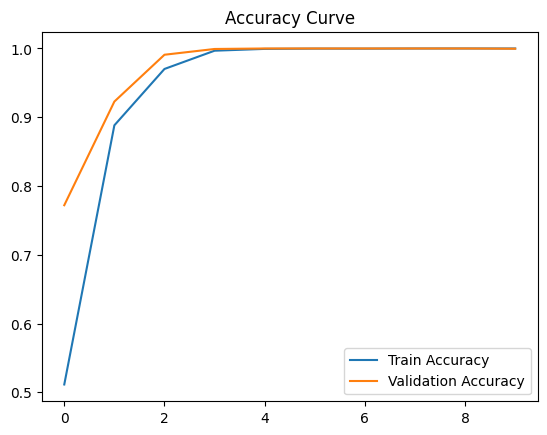

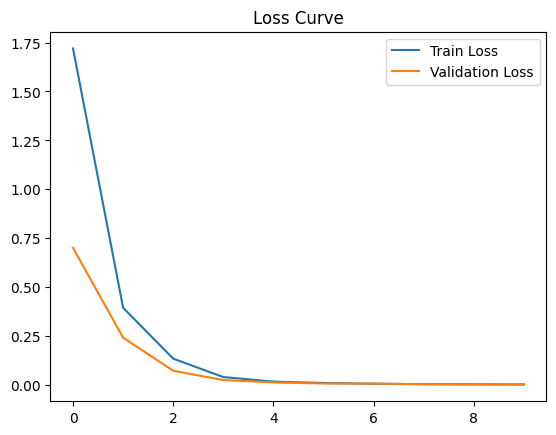

In [16]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()


In [18]:
model.save("hand_gesture_model.keras")

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


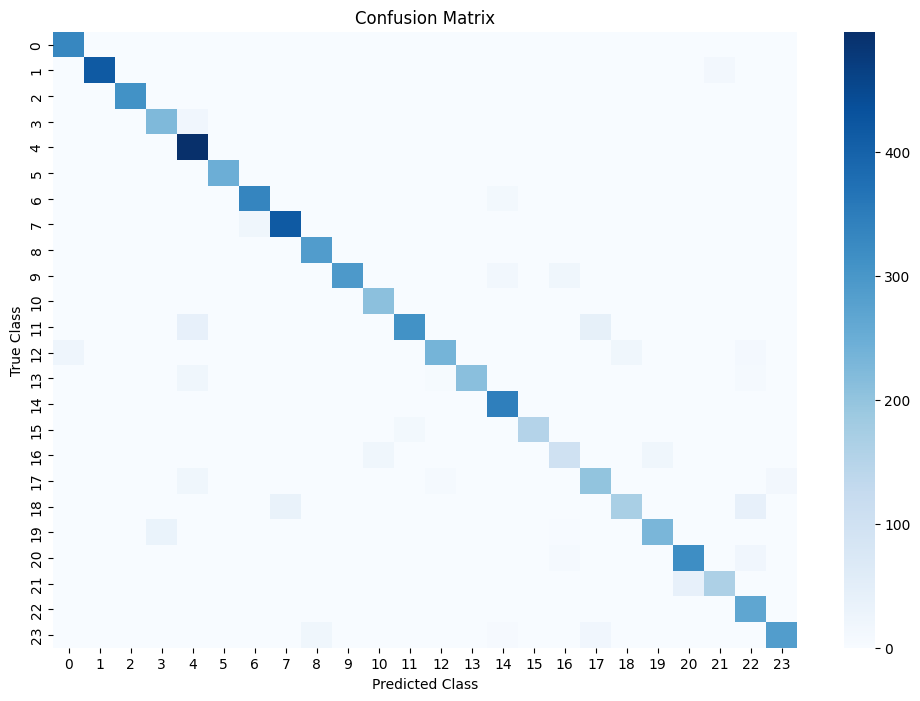

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predictions sur tout le test set
y_pred = model.predict(X_test).argmax(axis=1)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()


In [18]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      1.00      0.97       331
           1       1.00      0.97      0.98       432
           2       1.00      1.00      1.00       310
           3       0.88      0.92      0.90       245
           4       0.83      1.00      0.91       498
           5       1.00      1.00      1.00       247
           6       0.94      0.96      0.95       348
           7       0.92      0.95      0.94       436
           8       0.94      1.00      0.97       288
          10       1.00      0.89      0.94       331
          11       0.91      1.00      0.95       209
          12       0.96      0.78      0.86       394
          13       0.95      0.81      0.87       291
          14       1.00      0.86      0.92       246
          15       0.91      1.00      0.95       347
          16       0.99      0.93      0.96       164
          17       0.76      0.71      0.73       144
          18       0.76    

In [19]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


In [20]:
model.save("hand_gesture_model.keras")


In [22]:
import os

print(os.listdir())

['.config', 'sign_mnist_test.csv', 'sign_mnist_train.csv', 'hand_gesture_model.keras', 'sample_data']


In [41]:
from google.colab import output
from IPython.display import display, Javascript
from base64 import b64decode
import cv2
import numpy as np

# REGISTER PYTHON CALLBACK for JS → PYTHON communication
def take_photo_callback(data):
    global photo_data
    photo_data = data

output.register_callback('take_photo_callback', take_photo_callback)


In [42]:
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({video: true});

        document.body.appendChild(div);
        div.appendChild(video);

        video.srcObject = stream;
        await video.play();

        await new Promise(resolve => setTimeout(resolve, 3000));
 // attendre stabilisation

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getTracks()[0].stop();
        div.remove();

        const dataUrl = canvas.toDataURL('image/jpeg', quality);

        google.colab.kernel.invokeFunction(
          'take_photo_callback',
          [dataUrl],
          {}
        );
      }
      takePhoto(%f);
    ''' % quality)

    display(js)

    # attendre que la callback JS fournisse les données
    while 'photo_data' not in globals():
        pass

    data = photo_data
    del globals()['photo_data']

    # convertir base64 → jpeg
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)

    return filename


In [43]:
from google.colab import output

def take_photo_py(data):
    output.register_callback('take_photo_py', lambda x: x)


In [46]:
photo_path = take_photo()
photo_path


In [ ]:
from google.colab import drive
drive.mount('/content/drive')